Загрузка бибилиотек

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
np.random.seed(0)

Функции для оценки модели

In [56]:
def display_tree(dt, w, h):

    from sklearn import tree
    import matplotlib.pyplot as plt

    plt.figure(figsize=(w, h))

    tree.plot_tree(
        dt,
        filled=True,
        rounded=True,
        fontsize=14
    )

    plt.show()

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("Confusion matrix:\n", cm)

    return acc, prec, rec, cm

Загрузка данных

In [58]:
dataset = pd.read_csv("iris_binary.csv")
X = dataset[['sepal length (cm)',
             'sepal width (cm)',
             'petal length (cm)',
             'petal width (cm)']]
y = dataset['target']

In [59]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,7.0,3.2,4.7,1.4
1,6.4,3.2,2.1,3.5
2,6.9,3.1,4.9,1.5
3,5.5,2.3,4.0,1.3
4,6.5,2.8,7.6,4.5
...,...,...,...,...
95,6.7,3.0,5.2,2.3
96,6.3,2.5,5.0,1.9
97,6.5,3.0,3.2,2.9
98,6.2,3.4,2.9,3.1


In [60]:
y

0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
     ... 
95    2.0
96    2.0
97    2.0
98    2.0
99    2.0
Name: target, Length: 100, dtype: float64

Разбиение данных

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

Построение дерева решений с использованием индекса Джини

Accuracy: 0.9
Precision: 0.9166666666666667
Recall: 0.9
Confusion matrix:
 [[10  0]
 [ 2  8]]


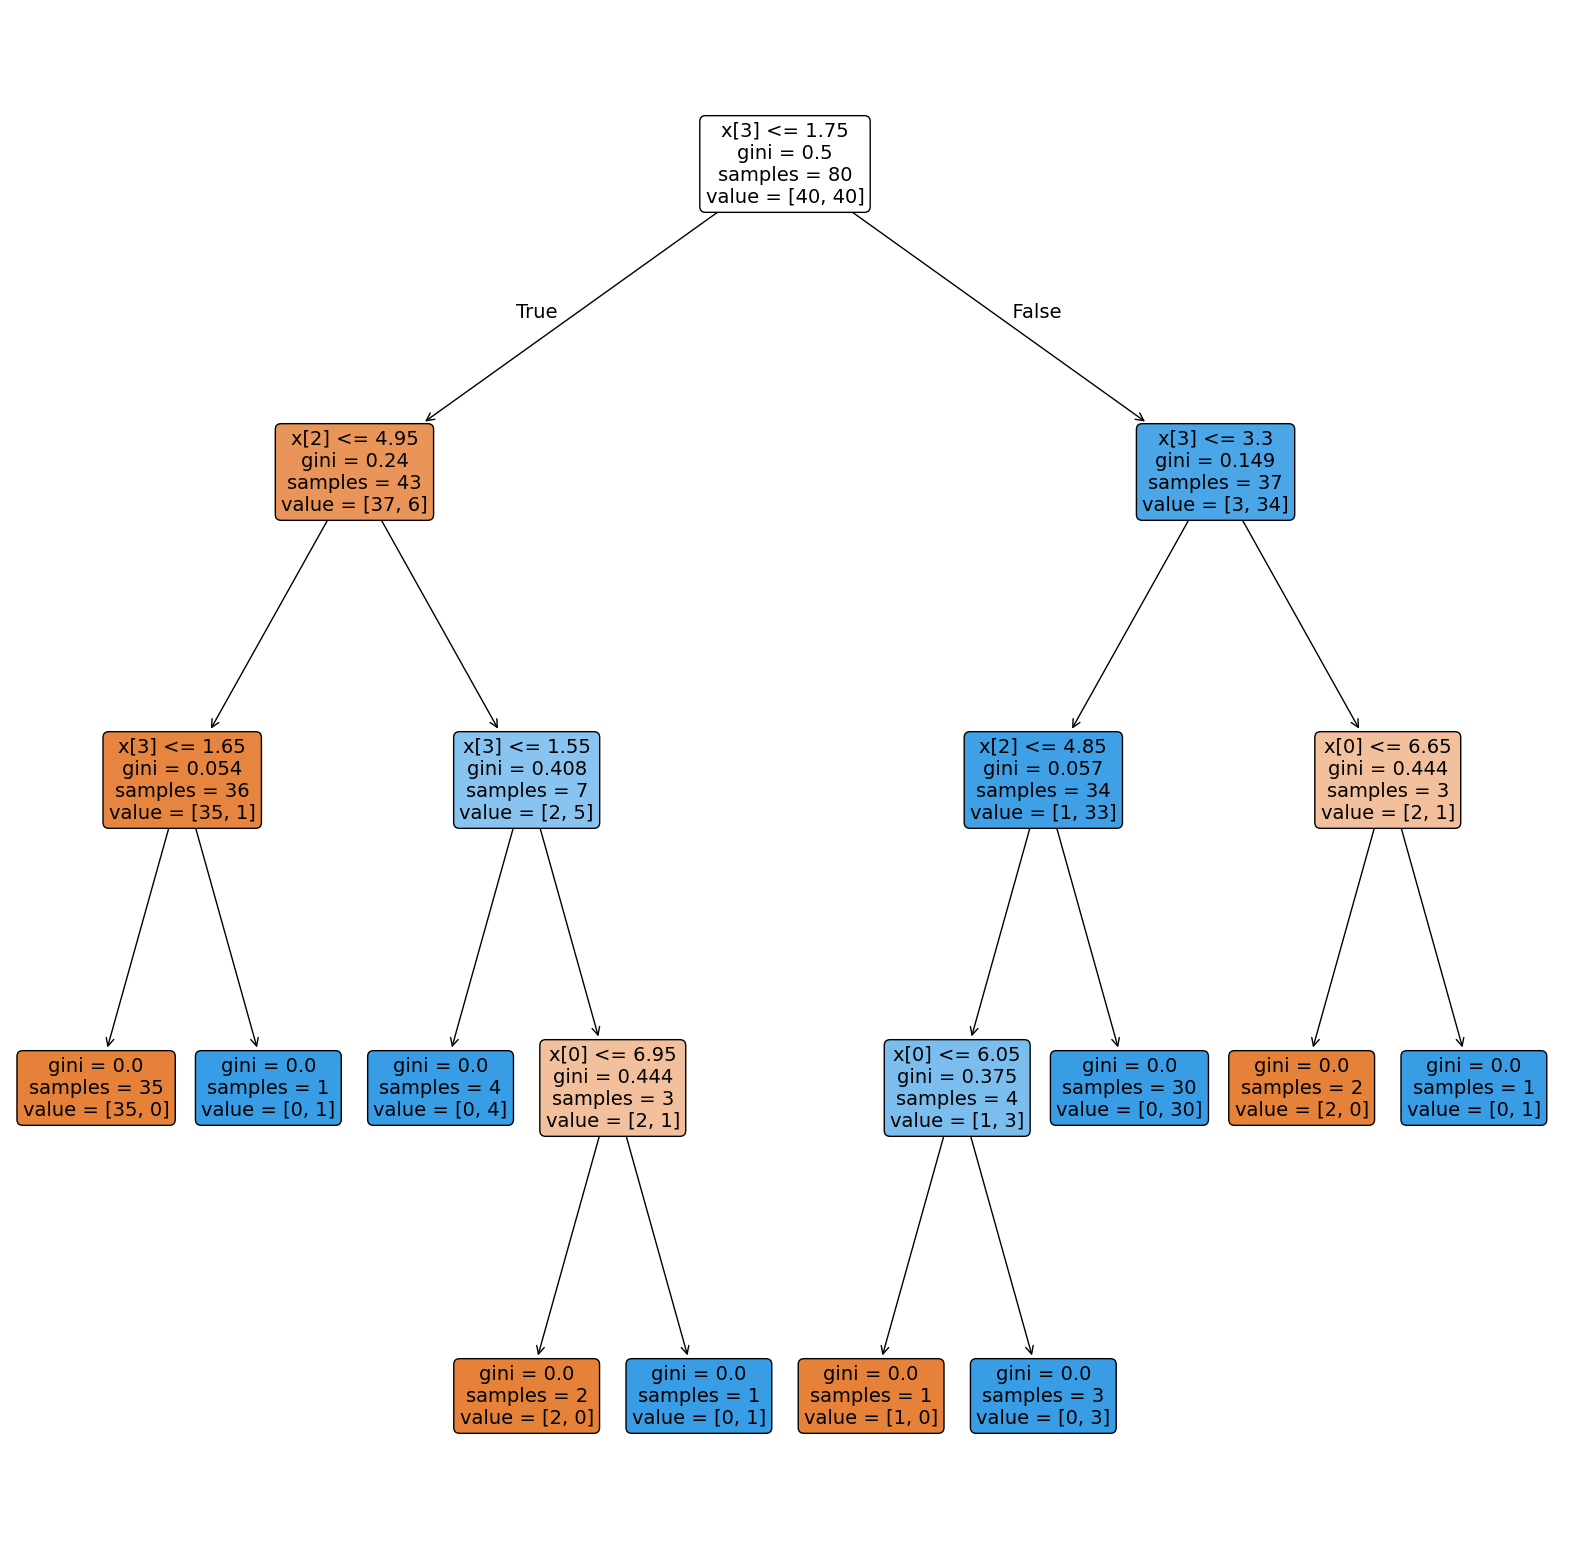

In [66]:
tree1 = DecisionTreeClassifier()
tree1.fit(X_train, y_train)

evaluate_model(tree1, X_test, y_test)
display_tree(tree1, 20, 20)

Построение дерева решений с использованием энтропии

Accuracy: 0.9
Precision: 0.9166666666666667
Recall: 0.9
Confusion matrix:
 [[10  0]
 [ 2  8]]


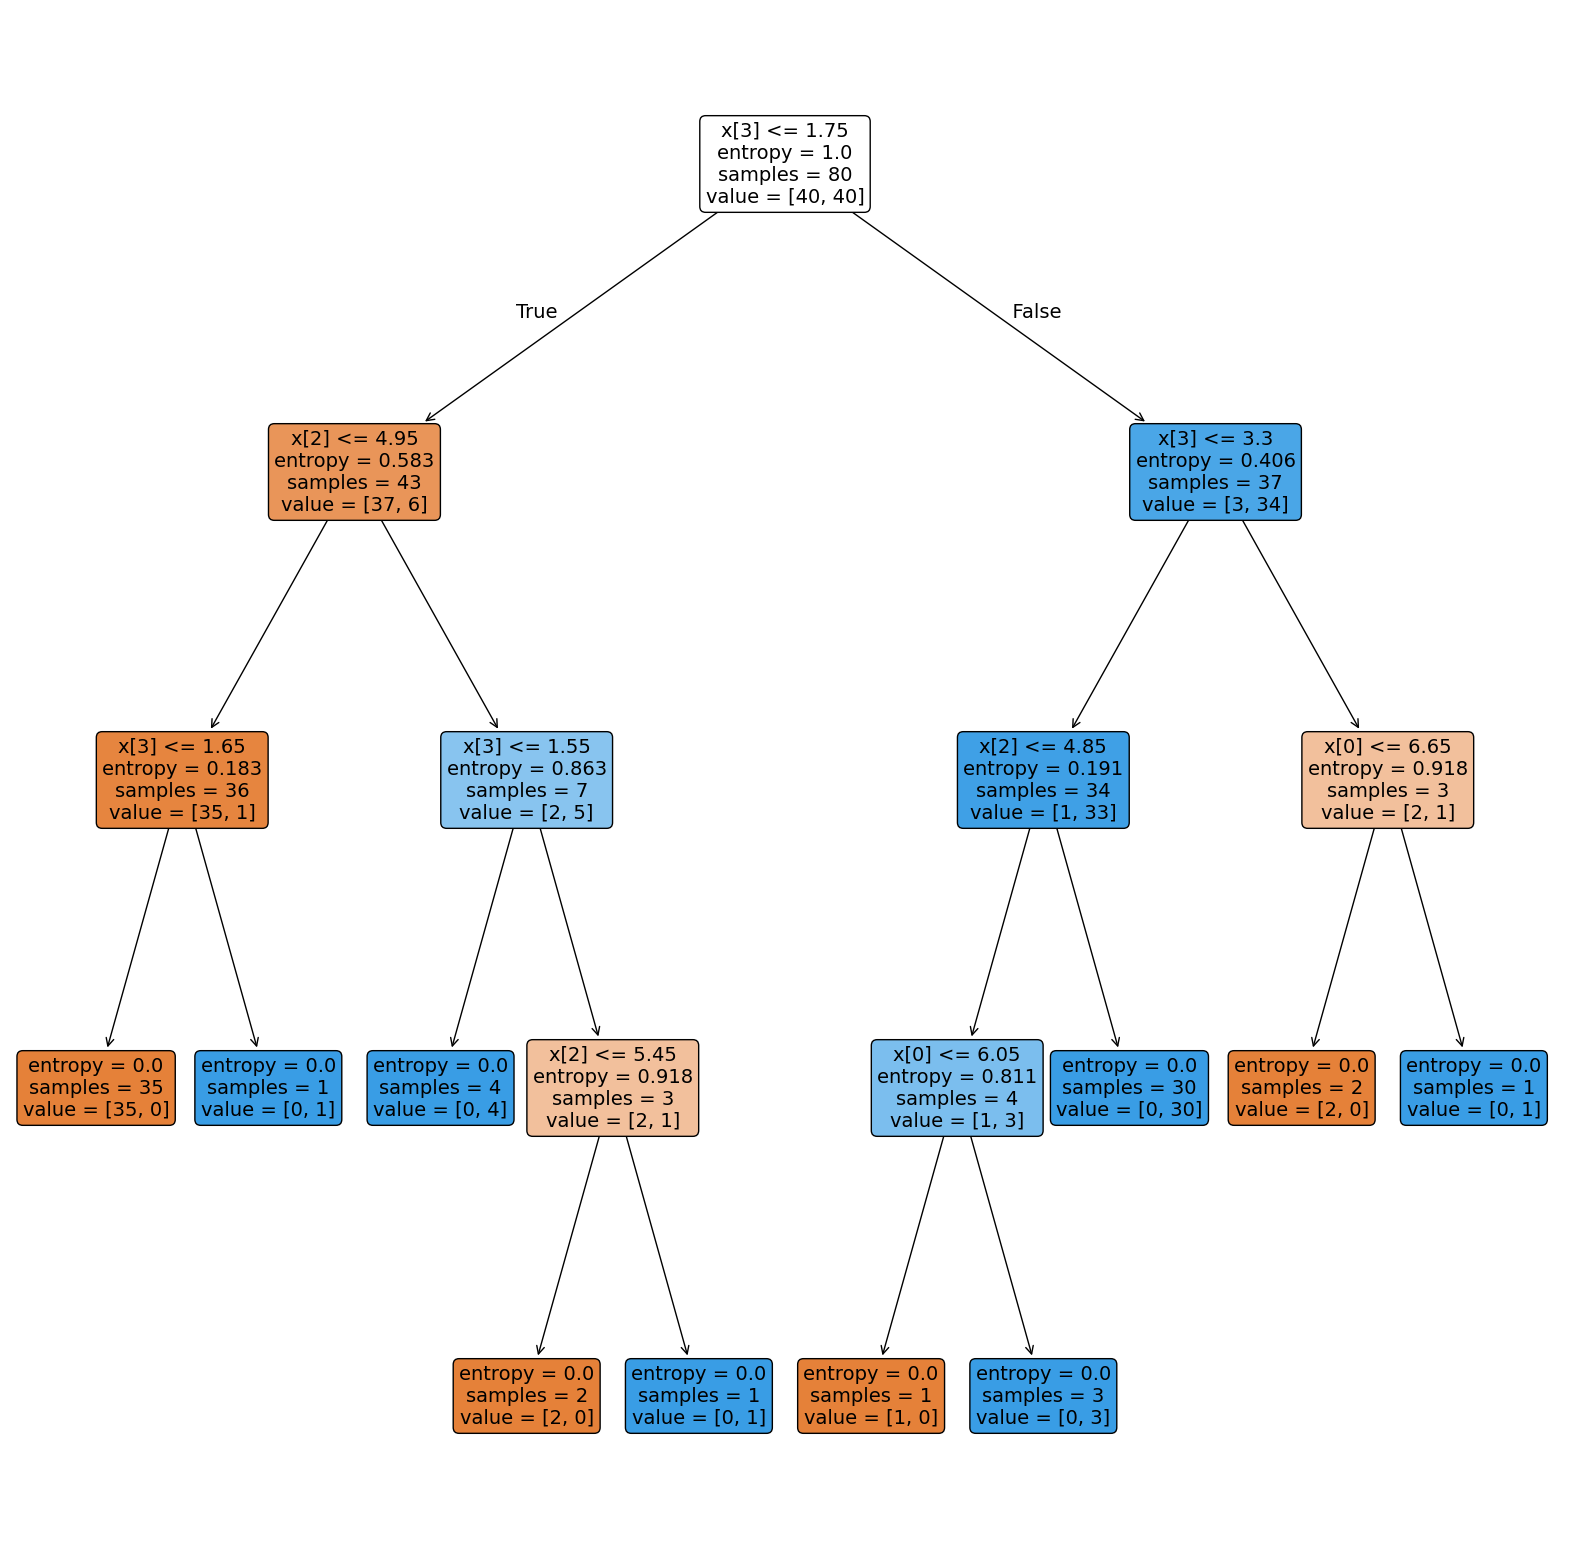

In [67]:
tree2 = DecisionTreeClassifier(criterion='entropy')
tree2.fit(X_train, y_train)

evaluate_model(tree2, X_test, y_test)
display_tree(tree2, 20, 20)

Модель с ограниченной глубиной

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Confusion matrix:
 [[10  0]
 [ 0 10]]


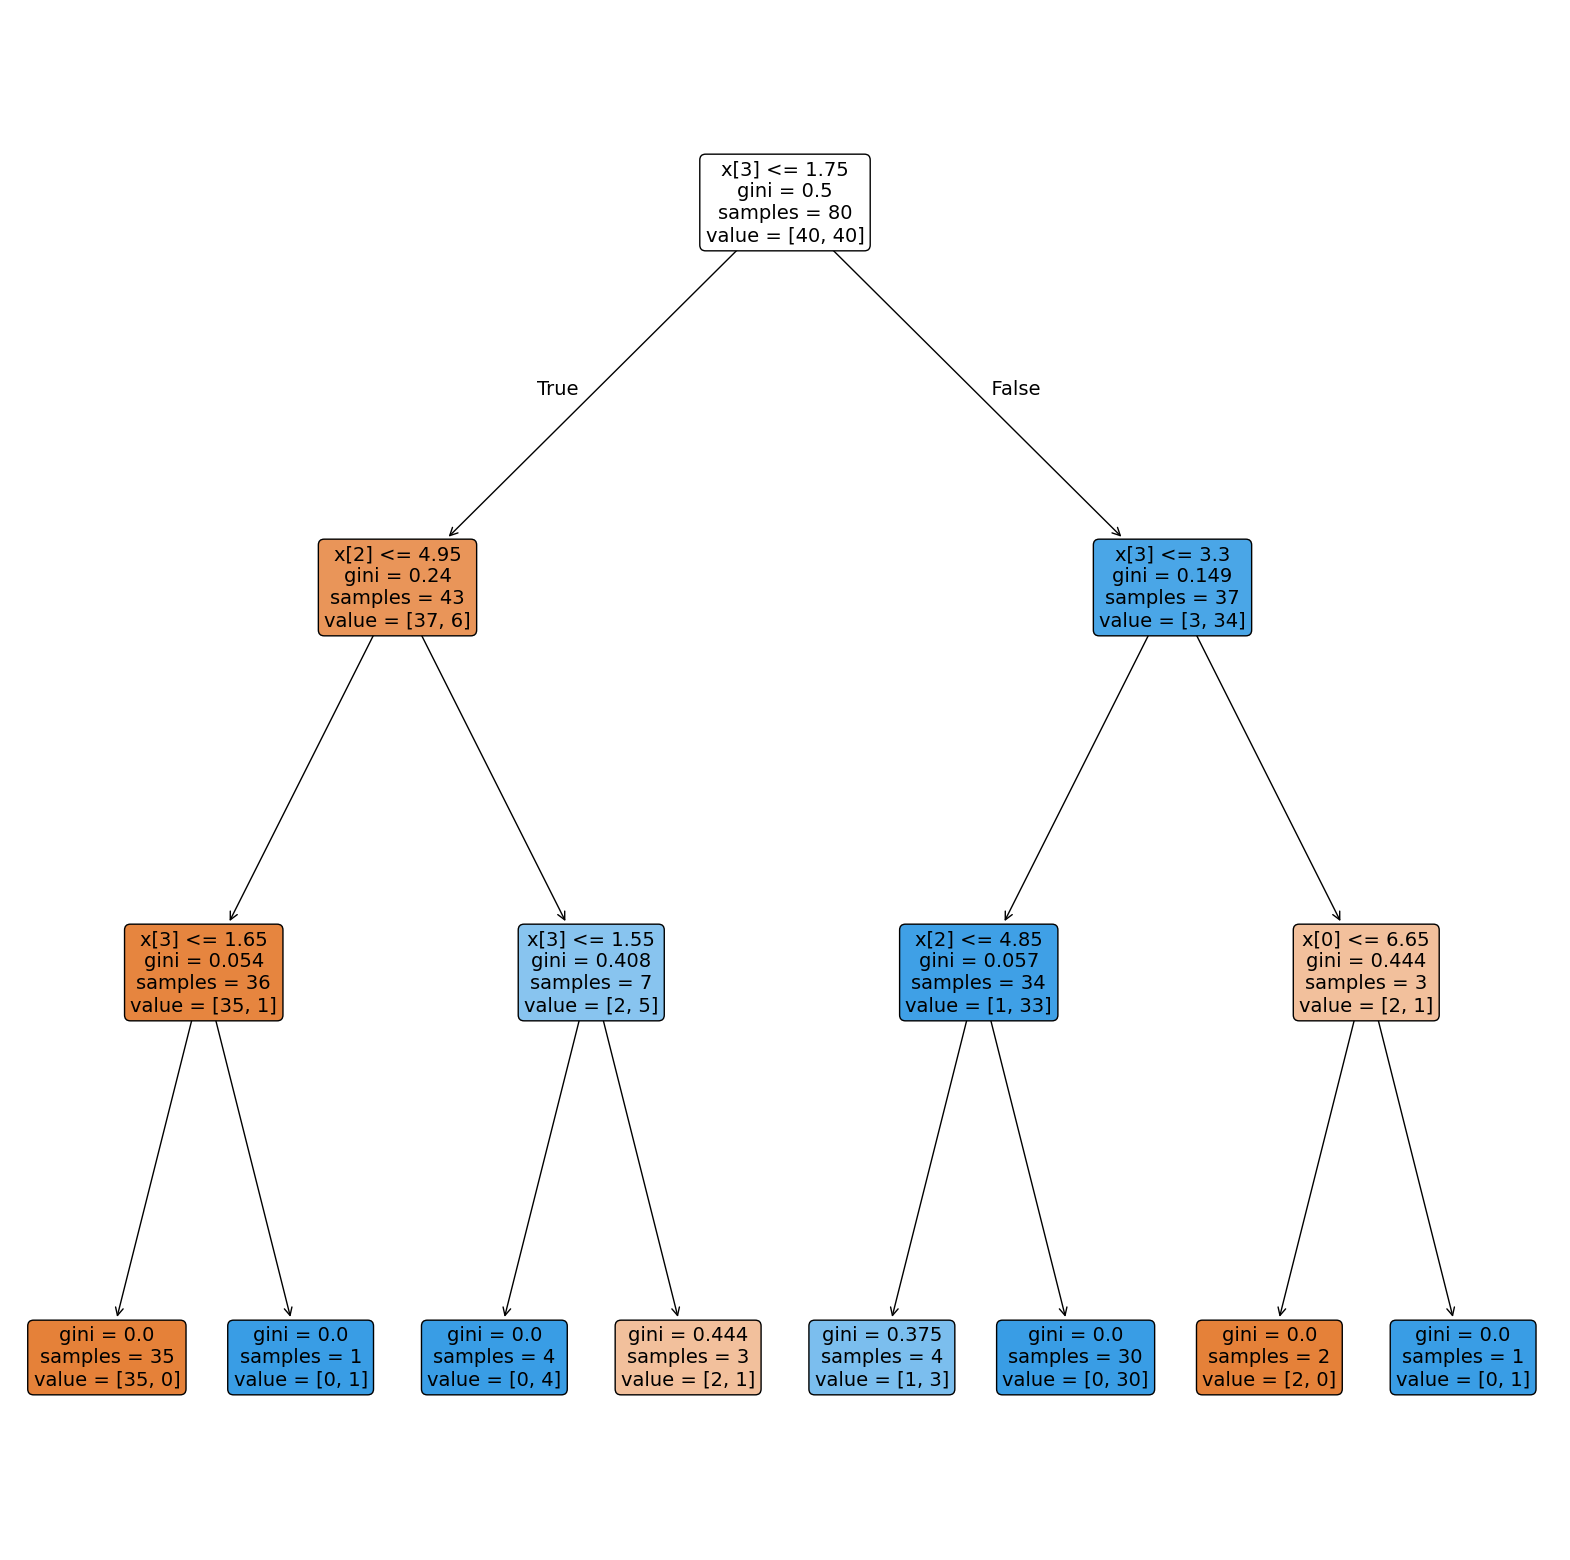

In [71]:
tree3 = DecisionTreeClassifier(max_depth=3)
tree3.fit(X_train, y_train)

evaluate_model(tree3, X_test, y_test)
display_tree(tree3, 20, 20)

Модель с ограниченным количеством объектов в листе

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Confusion matrix:
 [[10  0]
 [ 0 10]]


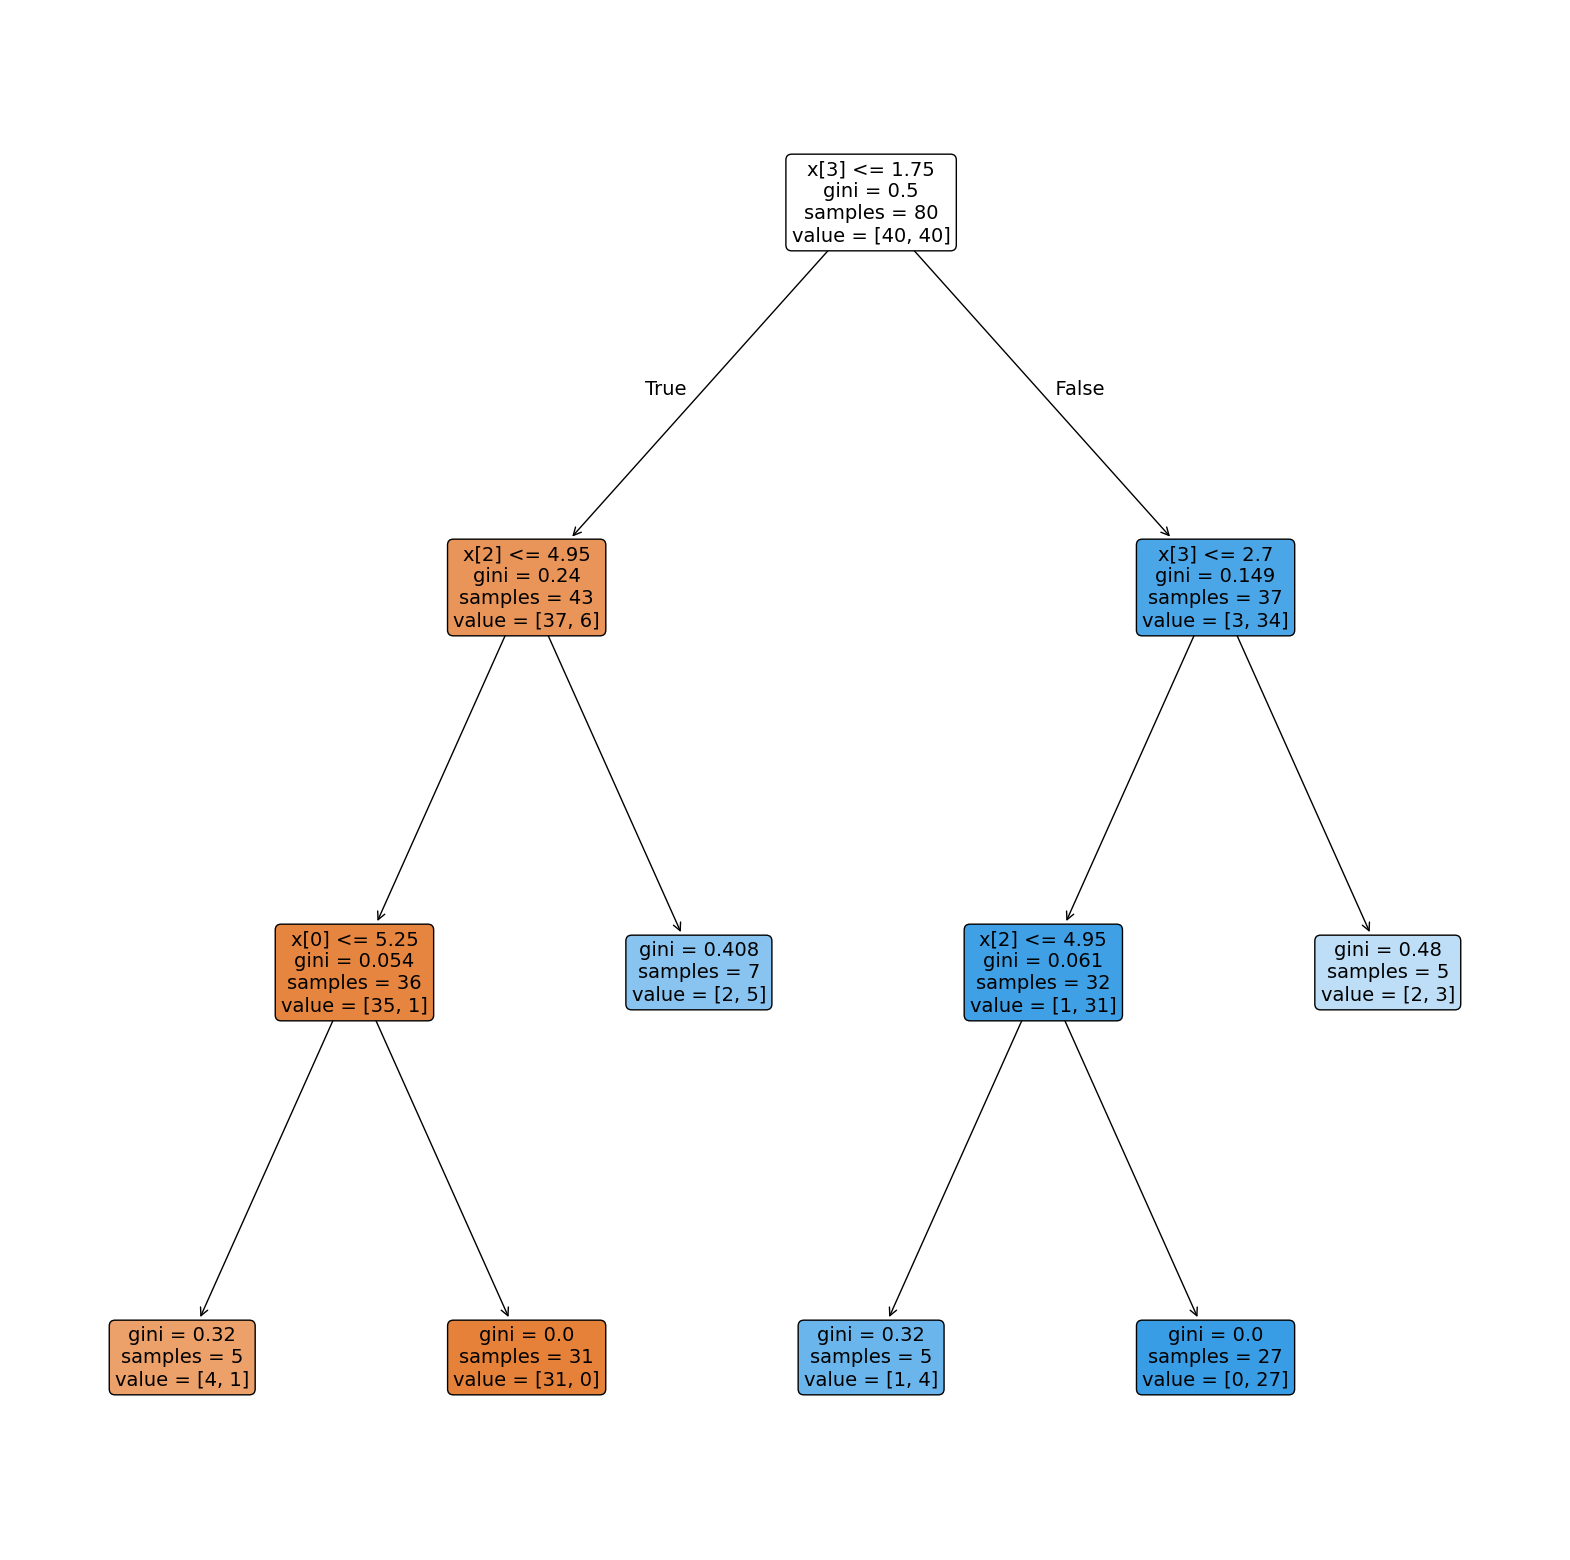

In [72]:
tree4 = DecisionTreeClassifier(min_samples_leaf=5)
tree4.fit(X_train, y_train)

evaluate_model(tree4, X_test, y_test)
display_tree(tree4, 20, 20)